# 02 — Feature Engineering

Builds the shared feature set every downstream module (ETA, forecasting, recommendation, fraud, optimization) is trained on.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 40)


In [2]:
from data_prep import clean_raw, add_core_features, build_model_matrix

train = add_core_features(clean_raw('../data/train_raw.csv', is_train=True))
test = add_core_features(clean_raw('../data/test_raw.csv', is_train=False))
train.to_parquet('../data/processed/train_clean.parquet')
test.to_parquet('../data/processed/test_clean.parquet')
train.shape, test.shape

((45593, 30), (11399, 29))

## Engineered features

- **`distance_km`** — haversine distance between restaurant and delivery coordinates, capped at 30km (corrupted-coordinate outliers)
- **Datetime features** — `order_hour`, `order_dow`, `is_weekend`, `is_rush_hour`
- **`prep_time_min`** — minutes between order placed and picked up (handles midnight rollover)
- **`traffic_ordinal`** — Low/Medium/High/Jam mapped to 0-3
- **`distance_traffic_interaction`** — distance × traffic, the single strongest engineered predictor
- **`bad_weather`**, **`is_festival`** — binary flags
- One-hot encoding for `Type_of_order`, `Type_of_vehicle`, `City`, with train/test column alignment via `build_model_matrix()`

In [3]:
X = build_model_matrix(train)
X.head()

,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,distance_km,order_hour,order_dow,is_weekend,is_rush_hour,prep_time_min,traffic_ordinal,distance_traffic_interaction,bad_weather,is_festival,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Semi-Urban,City_Urban
0,37.0,4.9,2,0.0,3.025149,11.0,5,1,0,15.0,2,6.050299,0,0,False,False,True,False,True,False,False,True
1,34.0,4.5,2,1.0,20.183530,19.0,4,0,1,5.0,3,60.550589,1,0,False,False,True,False,False,True,False,False
2,23.0,4.4,0,1.0,1.552758,8.0,5,1,1,15.0,0,0.000000,1,0,True,False,False,False,True,False,False,True
3,38.0,4.7,0,1.0,7.790401,18.0,1,0,1,10.0,1,7.790401,0,0,False,False,False,False,True,False,False,False
4,32.0,4.6,1,1.0,6.210138,13.0,5,1,1,15.0,2,12.420276,0,0,False,False,True,False,False,True,False,False


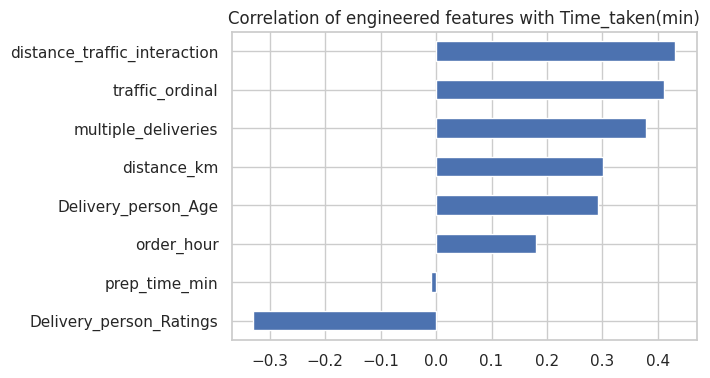

In [4]:
corr_with_target = train[['distance_km','traffic_ordinal','distance_traffic_interaction',
                           'prep_time_min','order_hour','Delivery_person_Ratings',
                           'Delivery_person_Age','multiple_deliveries']].corrwith(train['Time_taken(min)']).sort_values()
plt.figure(figsize=(6,4))
corr_with_target.plot(kind='barh')
plt.title('Correlation of engineered features with Time_taken(min)')
plt.show()